In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
categories = ['bottle',
'bowl',
'car',
'chair',
'clock',
'cup',
'fork',
'keyboard',
'knife',
'laptop',
'microwave',
'mouse',
'oven',
'potted plant',
'sink',
'stop sign',
'toilet',
'tv']


# Add 1 void label.
# _COCO_PANOPTIC_TRAIN_ID_TO_EVAL_ID = (
#     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34, 35,
#      36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
#      67, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 92, 93, 95, 100, 107, 109, 112,
#      118, 119, 122, 125, 128, 130, 133, 138, 141, 144, 145, 147, 148, 149, 151, 154, 155, 156, 159, 161, 166, 168, 171,
#      175, 176, 177, 178, 180, 181, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199,
#      200, 0])

# _COCO_PANOPTIC_EVAL_ID_TO_TRAIN_ID = {
#     v: k for k, v in enumerate(_COCO_PANOPTIC_TRAIN_ID_TO_EVAL_ID[:-1])
# }

# _COCO_PANOPTIC_THING_LIST = list(range(80))  # the first 80 classes are `thing` classes

# from https://github.com/bowenc0221/panoptic-deeplab/blob/master/segmentation/data/datasets/coco_panoptic.py
COCO_CATEGORIES = [
    {"color": [220, 20, 60], "isthing": 1, "id": 1, "name": "person"},
    {"color": [119, 11, 32], "isthing": 1, "id": 2, "name": "bicycle"},
    {"color": [0, 0, 142], "isthing": 1, "id": 3, "name": "car"},
    {"color": [0, 0, 230], "isthing": 1, "id": 4, "name": "motorcycle"},
    {"color": [106, 0, 228], "isthing": 1, "id": 5, "name": "airplane"},
    {"color": [0, 60, 100], "isthing": 1, "id": 6, "name": "bus"},
    {"color": [0, 80, 100], "isthing": 1, "id": 7, "name": "train"},
    {"color": [0, 0, 70], "isthing": 1, "id": 8, "name": "truck"},
    {"color": [0, 0, 192], "isthing": 1, "id": 9, "name": "boat"},
    {"color": [250, 170, 30], "isthing": 1, "id": 10, "name": "traffic light"},
    {"color": [100, 170, 30], "isthing": 1, "id": 11, "name": "fire hydrant"},
    {"color": [220, 220, 0], "isthing": 1, "id": 13, "name": "stop sign"},
    {"color": [175, 116, 175], "isthing": 1, "id": 14, "name": "parking meter"},
    {"color": [250, 0, 30], "isthing": 1, "id": 15, "name": "bench"},
    {"color": [165, 42, 42], "isthing": 1, "id": 16, "name": "bird"},
    {"color": [255, 77, 255], "isthing": 1, "id": 17, "name": "cat"},
    {"color": [0, 226, 252], "isthing": 1, "id": 18, "name": "dog"},
    {"color": [182, 182, 255], "isthing": 1, "id": 19, "name": "horse"},
    {"color": [0, 82, 0], "isthing": 1, "id": 20, "name": "sheep"},
    {"color": [120, 166, 157], "isthing": 1, "id": 21, "name": "cow"},
    {"color": [110, 76, 0], "isthing": 1, "id": 22, "name": "elephant"},
    {"color": [174, 57, 255], "isthing": 1, "id": 23, "name": "bear"},
    {"color": [199, 100, 0], "isthing": 1, "id": 24, "name": "zebra"},
    {"color": [72, 0, 118], "isthing": 1, "id": 25, "name": "giraffe"},
    {"color": [255, 179, 240], "isthing": 1, "id": 27, "name": "backpack"},
    {"color": [0, 125, 92], "isthing": 1, "id": 28, "name": "umbrella"},
    {"color": [209, 0, 151], "isthing": 1, "id": 31, "name": "handbag"},
    {"color": [188, 208, 182], "isthing": 1, "id": 32, "name": "tie"},
    {"color": [0, 220, 176], "isthing": 1, "id": 33, "name": "suitcase"},
    {"color": [255, 99, 164], "isthing": 1, "id": 34, "name": "frisbee"},
    {"color": [92, 0, 73], "isthing": 1, "id": 35, "name": "skis"},
    {"color": [133, 129, 255], "isthing": 1, "id": 36, "name": "snowboard"},
    {"color": [78, 180, 255], "isthing": 1, "id": 37, "name": "sports ball"},
    {"color": [0, 228, 0], "isthing": 1, "id": 38, "name": "kite"},
    {"color": [174, 255, 243], "isthing": 1, "id": 39, "name": "baseball bat"},
    {"color": [45, 89, 255], "isthing": 1, "id": 40, "name": "baseball glove"},
    {"color": [134, 134, 103], "isthing": 1, "id": 41, "name": "skateboard"},
    {"color": [145, 148, 174], "isthing": 1, "id": 42, "name": "surfboard"},
    {"color": [255, 208, 186], "isthing": 1, "id": 43, "name": "tennis racket"},
    {"color": [197, 226, 255], "isthing": 1, "id": 44, "name": "bottle"},
    {"color": [171, 134, 1], "isthing": 1, "id": 46, "name": "wine glass"},
    {"color": [109, 63, 54], "isthing": 1, "id": 47, "name": "cup"},
    {"color": [207, 138, 255], "isthing": 1, "id": 48, "name": "fork"},
    {"color": [151, 0, 95], "isthing": 1, "id": 49, "name": "knife"},
    {"color": [9, 80, 61], "isthing": 1, "id": 50, "name": "spoon"},
    {"color": [84, 105, 51], "isthing": 1, "id": 51, "name": "bowl"},
    {"color": [74, 65, 105], "isthing": 1, "id": 52, "name": "banana"},
    {"color": [166, 196, 102], "isthing": 1, "id": 53, "name": "apple"},
    {"color": [208, 195, 210], "isthing": 1, "id": 54, "name": "sandwich"},
    {"color": [255, 109, 65], "isthing": 1, "id": 55, "name": "orange"},
    {"color": [0, 143, 149], "isthing": 1, "id": 56, "name": "broccoli"},
    {"color": [179, 0, 194], "isthing": 1, "id": 57, "name": "carrot"},
    {"color": [209, 99, 106], "isthing": 1, "id": 58, "name": "hot dog"},
    {"color": [5, 121, 0], "isthing": 1, "id": 59, "name": "pizza"},
    {"color": [227, 255, 205], "isthing": 1, "id": 60, "name": "donut"},
    {"color": [147, 186, 208], "isthing": 1, "id": 61, "name": "cake"},
    {"color": [153, 69, 1], "isthing": 1, "id": 62, "name": "chair"},
    {"color": [3, 95, 161], "isthing": 1, "id": 63, "name": "couch"},
    {"color": [163, 255, 0], "isthing": 1, "id": 64, "name": "potted plant"},
    {"color": [119, 0, 170], "isthing": 1, "id": 65, "name": "bed"},
    {"color": [0, 182, 199], "isthing": 1, "id": 67, "name": "dining table"},
    {"color": [0, 165, 120], "isthing": 1, "id": 70, "name": "toilet"},
    {"color": [183, 130, 88], "isthing": 1, "id": 72, "name": "tv"},
    {"color": [95, 32, 0], "isthing": 1, "id": 73, "name": "laptop"},
    {"color": [130, 114, 135], "isthing": 1, "id": 74, "name": "mouse"},
    {"color": [110, 129, 133], "isthing": 1, "id": 75, "name": "remote"},
    {"color": [166, 74, 118], "isthing": 1, "id": 76, "name": "keyboard"},
    {"color": [219, 142, 185], "isthing": 1, "id": 77, "name": "cell phone"},
    {"color": [79, 210, 114], "isthing": 1, "id": 78, "name": "microwave"},
    {"color": [178, 90, 62], "isthing": 1, "id": 79, "name": "oven"},
    {"color": [65, 70, 15], "isthing": 1, "id": 80, "name": "toaster"},
    {"color": [127, 167, 115], "isthing": 1, "id": 81, "name": "sink"},
    {"color": [59, 105, 106], "isthing": 1, "id": 82, "name": "refrigerator"},
    {"color": [142, 108, 45], "isthing": 1, "id": 84, "name": "book"},
    {"color": [196, 172, 0], "isthing": 1, "id": 85, "name": "clock"},
    {"color": [95, 54, 80], "isthing": 1, "id": 86, "name": "vase"},
    {"color": [128, 76, 255], "isthing": 1, "id": 87, "name": "scissors"},
    {"color": [201, 57, 1], "isthing": 1, "id": 88, "name": "teddy bear"},
    {"color": [246, 0, 122], "isthing": 1, "id": 89, "name": "hair drier"},
    {"color": [191, 162, 208], "isthing": 1, "id": 90, "name": "toothbrush"},
    {"color": [255, 255, 128], "isthing": 0, "id": 92, "name": "banner"},
    {"color": [147, 211, 203], "isthing": 0, "id": 93, "name": "blanket"},
    {"color": [150, 100, 100], "isthing": 0, "id": 95, "name": "bridge"},
    {"color": [168, 171, 172], "isthing": 0, "id": 100, "name": "cardboard"},
    {"color": [146, 112, 198], "isthing": 0, "id": 107, "name": "counter"},
    {"color": [210, 170, 100], "isthing": 0, "id": 109, "name": "curtain"},
    {"color": [92, 136, 89], "isthing": 0, "id": 112, "name": "door-stuff"},
    {"color": [218, 88, 184], "isthing": 0, "id": 118, "name": "floor-wood"},
    {"color": [241, 129, 0], "isthing": 0, "id": 119, "name": "flower"},
    {"color": [217, 17, 255], "isthing": 0, "id": 122, "name": "fruit"},
    {"color": [124, 74, 181], "isthing": 0, "id": 125, "name": "gravel"},
    {"color": [70, 70, 70], "isthing": 0, "id": 128, "name": "house"},
    {"color": [255, 228, 255], "isthing": 0, "id": 130, "name": "light"},
    {"color": [154, 208, 0], "isthing": 0, "id": 133, "name": "mirror-stuff"},
    {"color": [193, 0, 92], "isthing": 0, "id": 138, "name": "net"},
    {"color": [76, 91, 113], "isthing": 0, "id": 141, "name": "pillow"},
    {"color": [255, 180, 195], "isthing": 0, "id": 144, "name": "platform"},
    {"color": [106, 154, 176], "isthing": 0, "id": 145, "name": "playingfield"},
    {"color": [230, 150, 140], "isthing": 0, "id": 147, "name": "railroad"},
    {"color": [60, 143, 255], "isthing": 0, "id": 148, "name": "river"},
    {"color": [128, 64, 128], "isthing": 0, "id": 149, "name": "road"},
    {"color": [92, 82, 55], "isthing": 0, "id": 151, "name": "roof"},
    {"color": [254, 212, 124], "isthing": 0, "id": 154, "name": "sand"},
    {"color": [73, 77, 174], "isthing": 0, "id": 155, "name": "sea"},
    {"color": [255, 160, 98], "isthing": 0, "id": 156, "name": "shelf"},
    {"color": [255, 255, 255], "isthing": 0, "id": 159, "name": "snow"},
    {"color": [104, 84, 109], "isthing": 0, "id": 161, "name": "stairs"},
    {"color": [169, 164, 131], "isthing": 0, "id": 166, "name": "tent"},
    {"color": [225, 199, 255], "isthing": 0, "id": 168, "name": "towel"},
    {"color": [137, 54, 74], "isthing": 0, "id": 171, "name": "wall-brick"},
    {"color": [135, 158, 223], "isthing": 0, "id": 175, "name": "wall-stone"},
    {"color": [7, 246, 231], "isthing": 0, "id": 176, "name": "wall-tile"},
    {"color": [107, 255, 200], "isthing": 0, "id": 177, "name": "wall-wood"},
    {"color": [58, 41, 149], "isthing": 0, "id": 178, "name": "water-other"},
    {"color": [183, 121, 142], "isthing": 0, "id": 180, "name": "window-blind"},
    {"color": [255, 73, 97], "isthing": 0, "id": 181, "name": "window-other"},
    {"color": [107, 142, 35], "isthing": 0, "id": 184, "name": "tree-merged"},
    {"color": [190, 153, 153], "isthing": 0, "id": 185, "name": "fence-merged"},
    {"color": [146, 139, 141], "isthing": 0, "id": 186, "name": "ceiling-merged"},
    {"color": [70, 130, 180], "isthing": 0, "id": 187, "name": "sky-other-merged"},
    {"color": [134, 199, 156], "isthing": 0, "id": 188, "name": "cabinet-merged"},
    {"color": [209, 226, 140], "isthing": 0, "id": 189, "name": "table-merged"},
    {"color": [96, 36, 108], "isthing": 0, "id": 190, "name": "floor-other-merged"},
    {"color": [96, 96, 96], "isthing": 0, "id": 191, "name": "pavement-merged"},
    {"color": [64, 170, 64], "isthing": 0, "id": 192, "name": "mountain-merged"},
    {"color": [152, 251, 152], "isthing": 0, "id": 193, "name": "grass-merged"},
    {"color": [208, 229, 228], "isthing": 0, "id": 194, "name": "dirt-merged"},
    {"color": [206, 186, 171], "isthing": 0, "id": 195, "name": "paper-merged"},
    {"color": [152, 161, 64], "isthing": 0, "id": 196, "name": "food-other-merged"},
    {"color": [116, 112, 0], "isthing": 0, "id": 197, "name": "building-other-merged"},
    {"color": [0, 114, 143], "isthing": 0, "id": 198, "name": "rock-merged"},
    {"color": [102, 102, 156], "isthing": 0, "id": 199, "name": "wall-other-merged"},
    {"color": [250, 141, 255], "isthing": 0, "id": 200, "name": "rug-merged"},
    {"id": 0, "name": "void"}
]

coco134labels = [d['name'] for d in COCO_CATEGORIES]

coco134labels_forlabels = [] 

# this way we keep all 134
for label in coco134labels:
    if label.split('-')[-1] == 'merged':
        newlabel = '-'.join(label.split('-')[:-1])
    else:
        newlabel = label
    coco134labels_forlabels.append(newlabel)
    

# newlabels = []
# for label in coco134labels:
#     splits = label.split('-')
#     if len(splits)>1:
#         newlabel  = label.split('-')[0]
#         if newlabel in newlabels:
#             print(newlabel, ' this exists')
#     else:
#         newlabel = label
        
#     newlabels.append(newlabel)
        
# # len(set(coco134labels_nohyphen)) = 128, 5 wall 2 window 2 floor

In [3]:
ostat = pd.read_csv('./results/dcb_object_stat_train.csv')

dcount={}
dsize={}
for cat in categories:
    ostat_by_task = ostat[ostat.task==cat].copy()
    ostat_by_task['relfreq'] =100*(ostat_by_task['count']/ostat_by_task[ostat_by_task.object==cat]['count'].item())
    # percents = np.array(count_by_task['count'].tolist())/count_by_task[count_by_task.object==cat]['count'].item()
    
    freqs=[] 
    sizes=[]
    for label in coco134labels_forlabels:
        freq = ostat_by_task[ ostat_by_task.object==label]['relfreq'].item()
        size = ostat_by_task[ ostat_by_task.object==label]['size'].item()
        if size == -99:
            assert freq==0
            size='N/A'
        freqs.append(freq)
        sizes.append(size)
    
    dcount[cat] = dict(zip(coco134labels_forlabels, freqs))
    dsize[cat] = dict(zip(coco134labels_forlabels, sizes))

In [13]:
# count = pd.read_csv('./results/dcb_object_coocurrence_train.csv')

# dcount={}

# for cat in categories:
#     count_by_task = count[count.task==cat].copy()
#     count_by_task['relfreq'] =count_by_task['count']/count_by_task[count_by_task.object==cat]['count'].item()
#     # percents = np.array(count_by_task['count'].tolist())/count_by_task[count_by_task.object==cat]['count'].item()
#     percents=[]
#     for label in coco134labels_forlabels:
#         freq = count_by_task[count_by_task.object==label]['relfreq']
#         if len(freq)==1:
#             percents.append(freq.item()*100)
#         elif len(freq)==0:
#             percents.append(0)
    
#     dcount[cat] = dict(zip(coco134labels_forlabels, percents))

In [14]:
# objectsize = pd.read_csv('./results/dcb_object_size_train.csv')
# objectsize = objectsize[~(objectsize['size']==-99)]

# dsize={}

# for cat in categories:
#     df_by_task = objectsize[objectsize.task==cat].copy()
#     percents=[]
#     for label in coco134labels_forlabels:
#         size = df_by_task[df_by_task.object==label]['size']
#         if len(size)==1:
#             percents.append(size.item())
#         elif len(size)==0:
#             percents.append('N/A')
            


    
#     dsize[cat] = dict(zip(coco134labels_forlabels, percents))

# TFP-AUC with stats

In [4]:
from pingouin import ttest

In [377]:
# def compute_cdf_auc(cdf):
#     if isinstance(cdf, dict):
#         auc = {}
#         for k, v in cdf.items():
#             auc[k] = v[0] + v[-1] + np.sum(v[1:-1])
#         return auc
#     else:
#         return cdf[0] + cdf[-1] + np.sum(cdf[1:-1])
    
# f1 = np.mean(np.array(list(cdf_none.values())), axis=0)
# f2 = np.mean(np.array(list(cdf_cat.values())), axis=0)

# print(compute_cdf_auc(f1))
# print(compute_cdf_auc(f2))

In [11]:
# for task in categories:
save=True

savepath = './results/DCBablation_SemSSupdated/'
for task in categories:
    filepath = savepath+ f'output_{task}.npy'
    out = np.load(filepath , allow_pickle=True).item()
    cdf_none = out['None']['cdf']
    
    # run stats
    tfp_df = pd.DataFrame()
    
    means =[]
    means_relative =[]
    ts = []
    dofs = []
    ps = []
    ds = []   
    
    for label in coco134labels:
        dcb_channel = coco134labels.index(label)
        cdf_cat = out[dcb_channel]['cdf']
        TFPAUC_diff = {}

        # get tfpauc different for each image
        for imgname in cdf_none.keys():
            TFPAUC_diff[imgname] = np.sum(cdf_cat[imgname]-cdf_none[imgname])

        TFPAUC_original = np.sum(np.mean(list(cdf_none.values()), axis=0)) # ceiling per. task
        mean = np.mean(list(TFPAUC_diff.values()))
        
        if mean == 0:
            means.append(mean)
            means_relative.append(mean/TFPAUC_original*100)
            ts.append(None)
            dofs.append(None)
            ps.append(None)
            ds.append(None)            
        else:
            tresult = ttest(list(TFPAUC_diff.values()), 0).round(2)

            means.append(mean)
            means_relative.append(mean/TFPAUC_original*100)
            ts.append(tresult['T'].item())
            dofs.append(tresult['dof'].item())
            ps.append(tresult['p-val'].item())
            ds.append(tresult['cohen-d'].item())

    tfp_df['dcb'] = coco134labels
    tfp_df['tfpauc'] = means
    tfp_df['tfpauc_relative'] = means_relative
    tfp_df['t-value']= ts
    tfp_df['dof']= dofs
    tfp_df['p-value']= ps
    tfp_df['cohen-d']= ds
    
    if save:
        tfp_df.to_csv(savepath+f'stat_{task}.csv', index=False)
        print(f'stat for {task} saved')
        

        


stat for bottle saved
stat for bowl saved
stat for car saved
stat for chair saved
stat for clock saved
stat for cup saved
stat for fork saved
stat for keyboard saved
stat for knife saved
stat for laptop saved
stat for microwave saved
stat for mouse saved
stat for oven saved
stat for potted plant saved
stat for sink saved
stat for stop sign saved
stat for toilet saved
stat for tv saved


# plot task-wise tfpauc


In [7]:
cat

'tv'

In [6]:
df

,dcb,tfpauc,tfpauc_relative,t-value,dof,p-value,cohen-d,label
0,person,0.000000,0.000000,NaN,NaN,NaN,NaN,person
1,bicycle,0.000000,0.000000,NaN,NaN,NaN,NaN,bicycle
2,car,0.000000,0.000000,NaN,NaN,NaN,NaN,car
3,motorcycle,0.000000,0.000000,NaN,NaN,NaN,NaN,motorcycle
4,airplane,0.000000,0.000000,NaN,NaN,NaN,NaN,airplane
...,...,...,...,...,...,...,...,...
128,food-other-merged,-0.053571,-1.456311,-1.00,55.0,0.32,0.13,food-other
129,building-other-merged,0.000000,0.000000,NaN,NaN,NaN,NaN,building-other
130,rock-merged,0.000000,0.000000,NaN,NaN,NaN,NaN,rock
131,wall-other-merged,0.000000,0.000000,NaN,NaN,NaN,NaN,wall-other


In [10]:
sort

,tfpauc_relative,label
94,-1.680672,net
0,0.000000,person
93,0.000000,mirror-stuff
92,0.000000,light
91,0.000000,house
...,...,...
121,5.042017,table
123,5.042017,pavement
69,5.882353,oven
116,8.403361,tree


In [15]:
sort

,tfpauc_relative,label
66,1.456311,keyboard
128,1.456311,food-other
110,0.970874,wall-stone
0,0.000000,person
88,0.000000,flower
...,...,...
59,-1.456311,bed
119,-1.941748,sky-other
86,-1.941748,door-stuff
132,-2.427184,rug


In [7]:
df

,dcb,tfpauc,tfpauc_relative,t-value,dof,p-value,cohen-d,label
0,person,0.000000,0.000000,NaN,NaN,NaN,NaN,person
1,bicycle,0.000000,0.000000,NaN,NaN,NaN,NaN,bicycle
2,car,0.000000,0.000000,NaN,NaN,NaN,NaN,car
3,motorcycle,0.000000,0.000000,NaN,NaN,NaN,NaN,motorcycle
4,airplane,0.000000,0.000000,NaN,NaN,NaN,NaN,airplane
...,...,...,...,...,...,...,...,...
129,building-other-merged,0.000000,0.000000,NaN,NaN,NaN,NaN,building-other
130,rock-merged,0.000000,0.000000,NaN,NaN,NaN,NaN,rock
131,wall-other-merged,0.000000,0.000000,NaN,NaN,NaN,NaN,wall-other
132,rug-merged,-0.060606,-1.769912,-0.33,32.0,0.74,0.06,rug


In [10]:
N_THINGS = 133 # 80 things + rest 53 are stuff categories + void cateogory
USE_TARGET = False

metric = 'tfpauc_relative'
metric_name = 'Search Efficiency'
targetdfs =[]
for i, cat in enumerate(categories):
    df = pd.read_csv(f'results/DCBablation_v4/stat_{cat}.csv')
    df['label'] = df['dcb'].replace(dict(zip(coco134labels, coco134labels_forlabels)))
    targetdfs.append(df[df['label']==cat])
targetdfs = pd.concat(targetdfs)

In [13]:
targetdfs.sort_values(by='tfpauc_relative').round(3)

,dcb,tfpauc,tfpauc_relative,t-value,dof,p-value,cohen-d,label
42,fork,-2.913,-94.366,-8.16,45.0,0.00,1.20,fork
45,bowl,-2.500,-85.366,-5.67,27.0,0.00,1.07,bowl
74,clock,-3.913,-82.569,-13.00,22.0,0.00,2.71,clock
41,cup,-2.964,-79.126,-10.56,54.0,0.00,1.42,cup
66,keyboard,-2.444,-77.876,-6.38,35.0,0.00,1.06,keyboard
64,mouse,-1.905,-72.727,-3.13,20.0,0.01,0.68,mouse
63,laptop,-2.167,-67.532,-5.64,23.0,0.00,1.15,laptop
39,bottle,-2.303,-67.257,-5.86,32.0,0.00,1.02,bottle
62,tv,-2.446,-66.505,-9.70,55.0,0.00,1.30,tv
58,potted plant,-1.933,-65.169,-4.89,29.0,0.00,0.89,potted plant


figures saved for tfpauc_relative


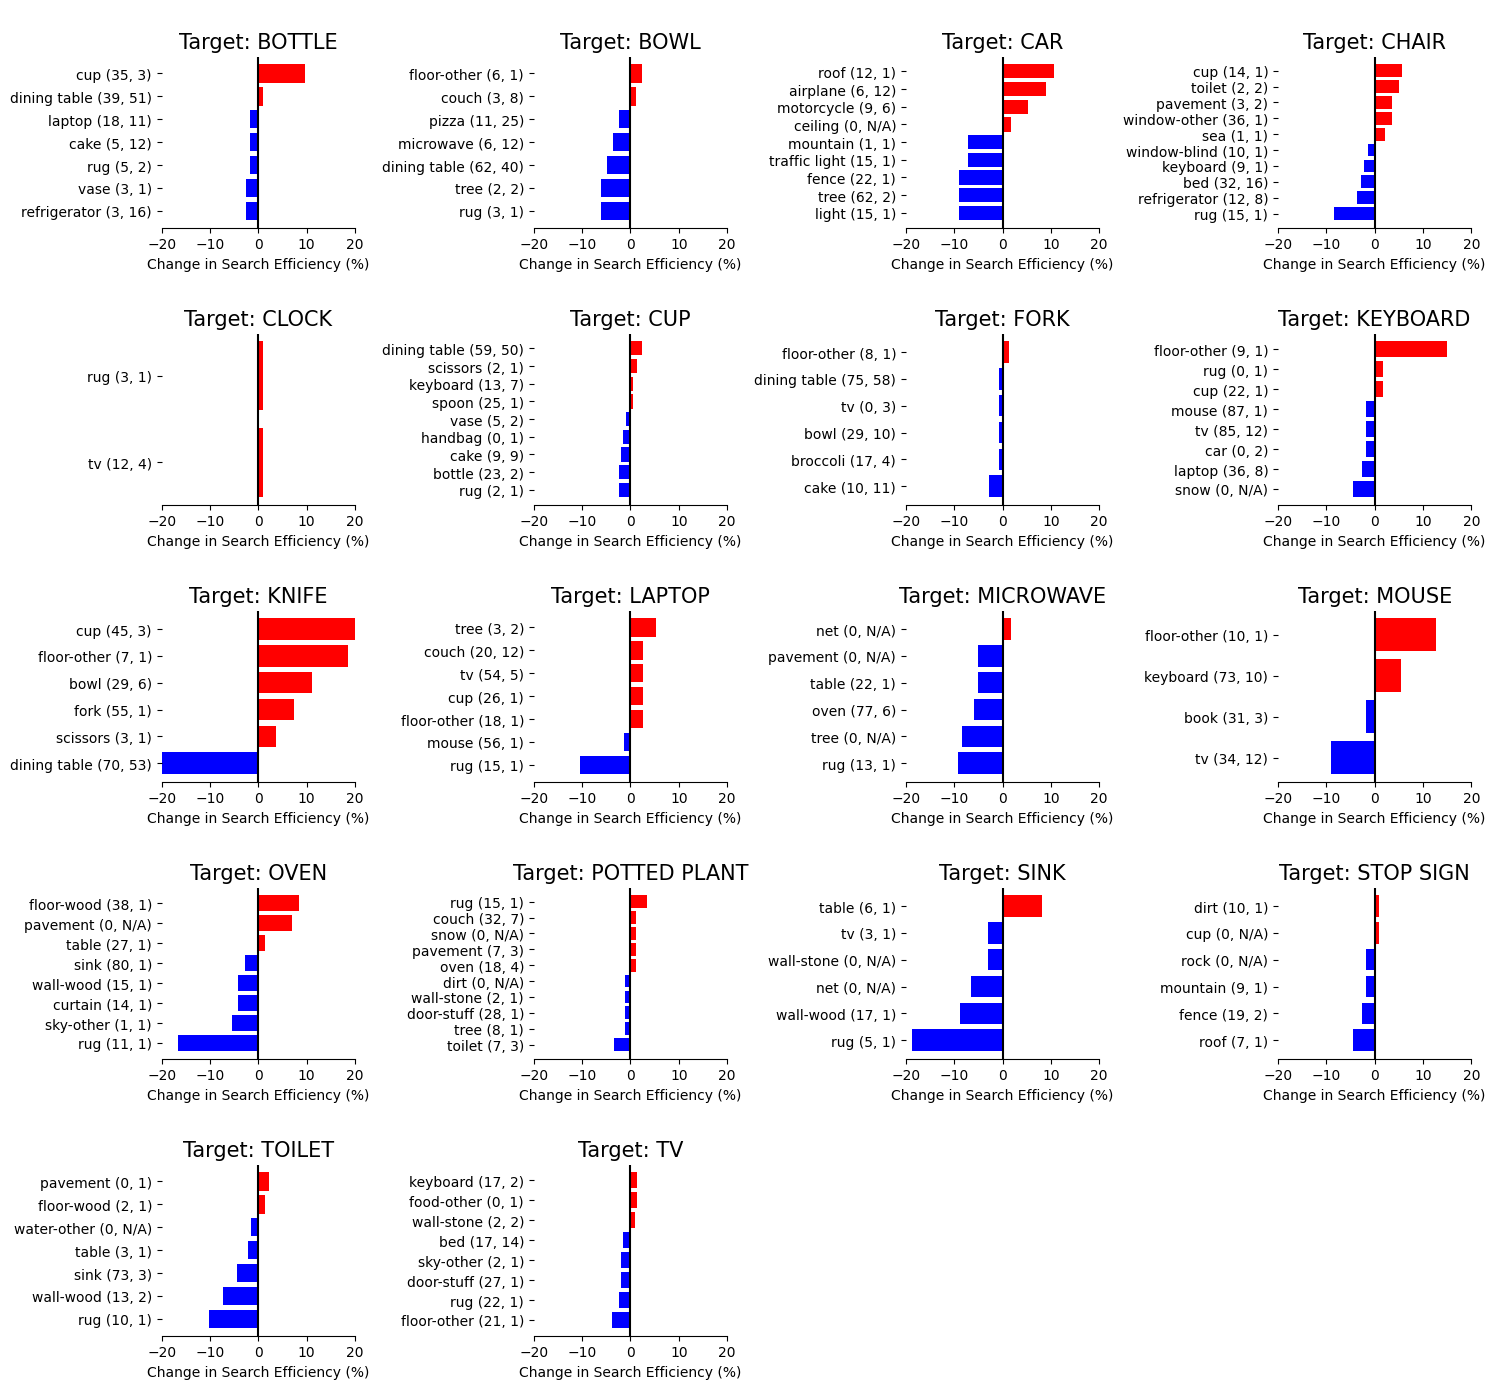

In [14]:
N_THINGS = 133 # 80 things + rest 53 are stuff categories + void cateogory
USE_TARGET = False

metric = 'tfpauc_relative'
metric_name = 'Search Efficiency'

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(15,14 ))

distractness, supportness=[],[]
for i, cat in enumerate(categories):
    df = pd.read_csv(f'results/DCBablation_v4/stat_{cat}.csv')
    df['label'] = df['dcb'].replace(dict(zip(coco134labels, coco134labels_forlabels)))
    
    if USE_TARGET:
        usetarget='yestarget'
    else:
        usetarget='notarget'
        df = df[~(df['label']==cat)].copy()

    k=5
    if N_THINGS==133:
        df = df[~(df['label']=='void')]
    sort= df.loc[:,[metric, 'label']].sort_values(by=metric, ascending=False)
    topk = sort[:k].copy()
    topk['color'] = ['red']*len(topk)
    distractness.append(topk[metric].mean())
    # topk= topk.sort_values(by='label')

    bottomk = sort[-k:].copy()
    bottomk['color'] = ['blue']*len(topk)
    supportness.append(bottomk[metric].mean())
    # bottomk= bottomk.sort_values(by='label')

    result = pd.concat([topk, bottomk])
    result = result[(result[metric]>0.0001) | (result[metric]<-0.0001)]

    if result[metric].nunique()==1:
        result= result.sort_values(by='label')

    ax = axes[int(i/4), i%4]

    if not len(result)>0:
        ax.set_xlim(0, 1)  # Set the x-axis limits
        ax.set_ylim(0, 1)  # Set the y-axis limits

        # Add "N/A" text in the center
        na_text = "N/A"
        ax.text(0.5, 0.5, na_text, fontsize=24, color='grey', ha='center', va='center')

        # Remove axis ticks and labels
        ax.axis('off')

    else:

        # fig, ax = plt.subplots(figsize=(4, 3))

        # Example data
        y_pos = np.arange(len(result))
        value = result[metric]

        uniquev = np.unique(value)

        if len(uniquev)==1:
            if uniquev[0] > 0:
                vmax= uniquev[0]
                vmin= 0-0.01
            else:
                vmax= 0+0.01
                vmin= uniquev[0]              
        else:
            vmax = max(max(value),0)
            vmin = min(min(value),0)

        ax.barh(y_pos, value, left=0, align='center', color=result['color'])
        ylabels =[]
        for oi, objectname in enumerate(result['label'].tolist()):
            # ylabel = result['label'].tolist()[oi]
            ylabel = objectname 
            count_percent = int(dcount[cat][objectname])#round(dcount[cat][objectname],0)
            size_percent = dsize[cat][objectname]#round(dcount[cat][objectname],0)
            ylabels.append(f'{ylabel} ({count_percent}, {size_percent})')

        ax.set_yticks(y_pos, labels=ylabels) #result['label']
        ax.invert_yaxis()  # labels read top-to-bottom
        # ax.set_xlim([vmin-0.005, vmax+0.005])
        # ax.set_xlim([-0.4, 0.4])
        ax.set_xlim([-20, 20])
        ax.axvline(0, color='black')

        # Move left y-axis and bottom x-axis to centre, passing through (0,0)
        # ax.spines['left'].set_position('center')
        # ax.spines['bottom'].set_position('center')

        # Eliminate upper and right axes
        ax.spines['left'].set_color('none')
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')


    ax.set_title(f'\nTarget: {str.upper(cat)}', fontsize=15)
    ax.set_xlabel(f'Change in {metric_name} (%)')

    # import matplotlib.patches as mpatches
    # blue_patch = mpatches.Patch(color='blue', label='Support')
    # red_patch = mpatches.Patch(color='red', label='Distractor')
    # ax.legend(handles=[blue_patch,red_patch])

    # plt.savefig(f'results/context_effect/{metric}_{cat}.pdf',  bbox_inches='tight')
    # plt.close()
    # plt.show()

print(f'figures saved for {metric}')
axes[-1, -1].axis('off')
axes[-1, -2].axis('off')
plt.tight_layout()
# plt.subplots_adjust(left=0.065, right=0.97, top=0.96, bottom=0.065, wspace=0.14)
plt.savefig(f'results/context_effect_v4/{N_THINGS}_{metric}_all_{usetarget}_relative_true.pdf',  bbox_inches='tight')
plt.show()
    
# remove target category
# include stuff categories
sdf = pd.DataFrame()
sdf['task'] = categories
sdf['average support'] = supportness
sdf['average distract'] = distractness
sdf.to_csv('results/context_effect_v4/support_distract_average.csv', index=False)

In [19]:
# save summation data too
N_THINGS = 133 # 80 things + rest 53 are stuff categories + void cateogory
USE_TARGET = False

metric = 'tfpauc_relative'
metric_name = 'Search Efficiency'

distractness, supportness=[],[]
for i, cat in enumerate(categories):
    df = pd.read_csv(f'results/DCBablation_v4/stat_{cat}.csv')
    df['label'] = df['dcb'].replace(dict(zip(coco134labels, coco134labels_forlabels)))
    
    if USE_TARGET:
        usetarget='yestarget'
    else:
        usetarget='notarget'
        df = df[~(df['label']==cat)].copy()

    k=5
    if N_THINGS==133:
        df = df[~(df['label']=='void')]
    sort= df.loc[:,[metric, 'label']].sort_values(by=metric, ascending=False)
    topk = sort[:k].copy()
    topk['color'] = ['red']*len(topk)
    distractness.append(topk[metric].sum())
    # topk= topk.sort_values(by='label')

    bottomk = sort[-k:].copy()
    bottomk['color'] = ['blue']*len(topk)
    supportness.append(bottomk[metric].sum())
    # bottomk= bottomk.sort_values(by='label')

    result = pd.concat([topk, bottomk])
    result = result[(result[metric]>0.0001) | (result[metric]<-0.0001)]

    if result[metric].nunique()==1:
        result= result.sort_values(by='label')

# remove target category
# include stuff categories
sdf = pd.DataFrame()
sdf['task'] = categories
sdf['average support'] = supportness
sdf['average distract'] = distractness
sdf.to_csv('results/context_effect_v4/support_distract_sum.csv', index=False)

# correlation plot
tfpauc X object properties (frequency & size)

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.stats import pearsonr
from scipy import stats

In [17]:
# get object stats
ost = ostat[~(ostat['size']== -99)].copy()

removed # from SD:  1
removed # from SD:  1
count x TFP-AUC % ; r = -0.106, 0.367
average mean estimate:  0.18879056047197634


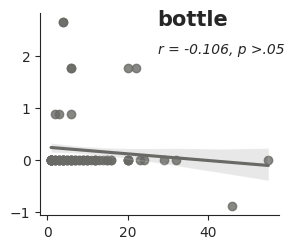

removed # from SD:  2
removed # from SD:  2
count x TFP-AUC % ; r = 0.084, 0.482
average mean estimate:  0.05081300813008129


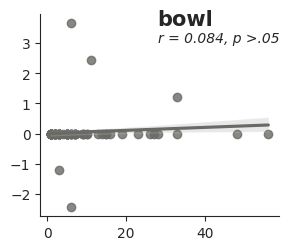

removed # from SD:  3
removed # from SD:  4
count x TFP-AUC % ; r = 0.106, 0.394
average mean estimate:  0.3464818763326225


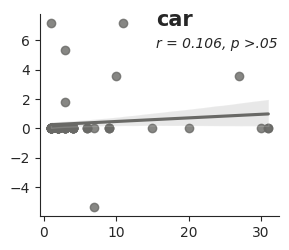

removed # from SD:  1
removed # from SD:  3
count x TFP-AUC % ; r = -0.015, 0.892
average mean estimate:  -0.024455857177794072


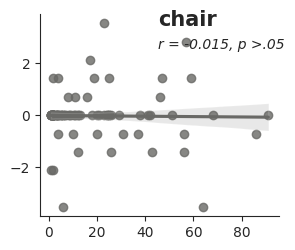

removed # from SD:  1
removed # from SD:  2
count x TFP-AUC % ; r = 0.0, 1.0
average mean estimate:  0.0


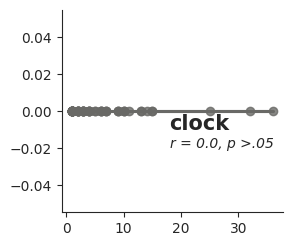

removed # from SD:  3
removed # from SD:  3
count x TFP-AUC % ; r = -0.017, 0.886
average mean estimate:  0.02623983206507478


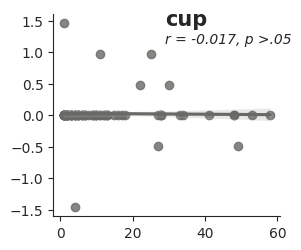

removed # from SD:  1
removed # from SD:  2
count x TFP-AUC % ; r = 0.478, 0.001
average mean estimate:  0.07185972980741592


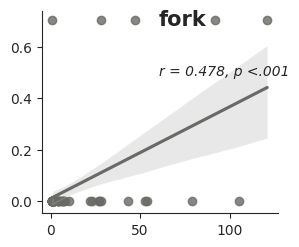

removed # from SD:  3
removed # from SD:  1
count x TFP-AUC % ; r = 0.126, 0.392
average mean estimate:  0.03687315634218289


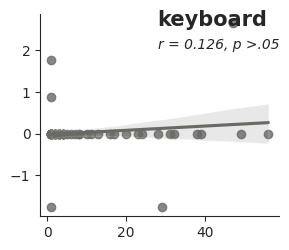

removed # from SD:  2
removed # from SD:  2
count x TFP-AUC % ; r = -0.447, 0.001
average mean estimate:  -0.4115226337448559


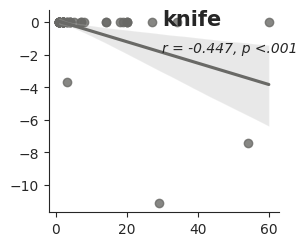

removed # from SD:  1
removed # from SD:  2
count x TFP-AUC % ; r = -0.19, 0.136
average mean estimate:  -0.2061430632859204


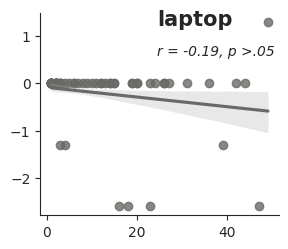

removed # from SD:  1
removed # from SD:  2
count x TFP-AUC % ; r = 0.153, 0.246
average mean estimate:  0.25637373593505197


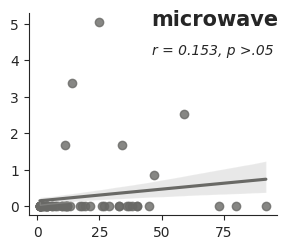

removed # from SD:  2
removed # from SD:  2
count x TFP-AUC % ; r = 0.284, 0.05
average mean estimate:  0.03787878787878788


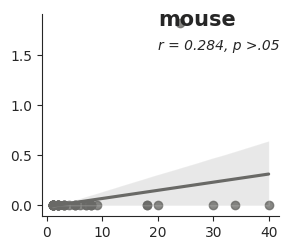

removed # from SD:  1
removed # from SD:  2
count x TFP-AUC % ; r = 0.03, 0.823
average mean estimate:  0.3113026819923372


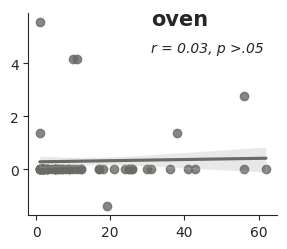

removed # from SD:  1
removed # from SD:  2
count x TFP-AUC % ; r = -0.071, 0.504
average mean estimate:  -0.012212994626282366


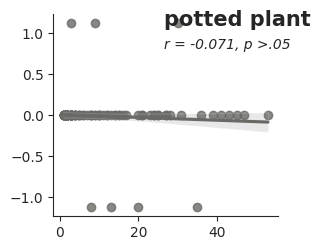

removed # from SD:  1
removed # from SD:  1
count x TFP-AUC % ; r = 0.063, 0.637
average mean estimate:  0.1613228473482557


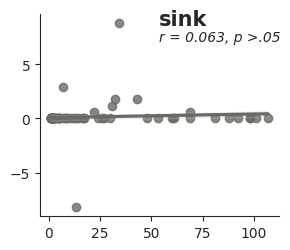

removed # from SD:  1
removed # from SD:  2
count x TFP-AUC % ; r = -0.013, 0.933
average mean estimate:  0.021258503401360544


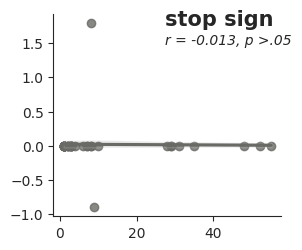

removed # from SD:  1
removed # from SD:  2
count x TFP-AUC % ; r = 0.407, 0.009
average mean estimate:  0.09191176470588236


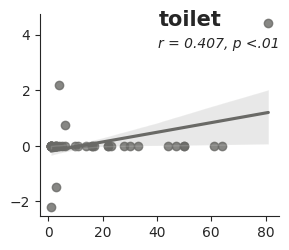

removed # from SD:  1
removed # from SD:  2
count x TFP-AUC % ; r = 0.207, 0.088
average mean estimate:  0.07035317292809908


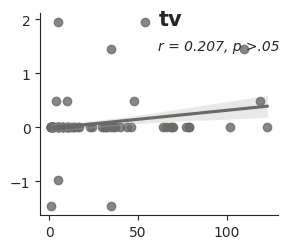

In [219]:
# category wise plots
SAVE=True
statmeasure = 'count'
metric = 'tfpauc_relative'
# taskwise plot
datalist = []
for task in categories:
    # if task=='knife':
    #     pass
    # else:
    #     continue
    # get tfpauc
    df = pd.read_csv(f'results/DCBablation_v4/stat_{task}.csv')
    df['label'] = df['dcb'].replace(dict(zip(coco134labels, coco134labels_forlabels)))
    dvalue = dict(zip(df['label'], df[metric]))
    
    # add tfpauc to object stat data
    data = ost[ost.task==task].copy()
    data[metric] = data.object.replace(dvalue)
    datalist.append(data)

    # Calculate the mean and standard deviation of the column
    mean_value = data[statmeasure].mean()
    std_value = data[statmeasure].std()

    # Define the cutoff values
    lower_cutoff = mean_value - 3 * std_value
    upper_cutoff = mean_value + 3 * std_value

    # Remove rows that are below or above 3 standard deviations from the mean
    data_filtered = data[(data[statmeasure] >= lower_cutoff) & (data[statmeasure] <= upper_cutoff)]

    print('removed # from SD: ', len(data)- len(data_filtered))

    data= data_filtered
    

    # Calculate the mean and standard deviation of the column
    mean_value = data[metric].mean()
    std_value = data[metric].std()

    # Define the cutoff values
    lower_cutoff = mean_value - 3 * std_value
    upper_cutoff = mean_value + 3 * std_value

    # Remove rows that are below or above 2 standard deviations from the mean
    data_filtered = data[(data[metric] >= lower_cutoff) & (data[metric] <= upper_cutoff)]

    print('removed # from SD: ', len(data)- len(data_filtered))

    data= data_filtered
    
    
    #########
    # draw plot
    ###########

    category = task

    slope, intercept, corr, pvalue, std_err = stats.linregress(data[statmeasure], data[metric])

    # corr = round(pearsonr(data['backN'], data['IOR'])[0],3)
    # pvalue =pearsonr(data['backN'], data['IOR'])[1]
    print(f'{statmeasure} x TFP-AUC % ; r = {round(corr,3)}, {round(pvalue,3)}')

    if pvalue<0.001:
        pvalue='p <.001'
    elif pvalue <0.01:
        pvalue='p <.01'
    elif pvalue <0.05:
        pvalue='p <.05'
    else:
        pvalue='p >.05'

    #     sns.set(style='white', font_scale=1.2)
    sns.set_style('white', rc={
        'xtick.bottom': True,
        'ytick.left': True,
    })
    # sns.set(rc={"xtick.bottom" : True})

    g = sns.JointGrid(data=data, x=statmeasure, y=metric) #height=5 #xlim=(0, 1), ylim=(0, 0.5)
    g = g.plot_joint(sns.regplot, color="#696966", x_ci=68, ci=68) # if 68-> SE #x_estimator=np.mean, 
    #     g = g.plot_marginals(sns.distplot, kde=False, bins=15, color="xkcd:bluey grey")
    #     g.ax_marg_x.set_axis_off()
    #     g.ax_marg_y.set_axis_off()
    mean = g.ax_joint.collections[0].get_offsets()[:, 1].mean()
    print('average mean estimate: ' , mean)
    g.ax_marg_x.remove()
    g.ax_marg_y.remove()

    if abs(data[metric].std())<0.01:
        g.ax_joint.text(max(data[statmeasure])- 0.5*max(data[statmeasure]), max(data[metric])-0.02, f'r = {round(corr,3)}, {pvalue}', fontstyle='italic')
        g.ax_joint.text(max(data[statmeasure])- 0.5*max(data[statmeasure]), max(data[metric])-0.01, task, fontweight="bold", fontsize=15)

    else:
        g.ax_joint.text(max(data[statmeasure])- 0.5*max(data[statmeasure]), max(data[metric])-1.0*data[metric].std(), f'r = {round(corr,3)}, {pvalue}', fontstyle='italic')
        g.ax_joint.text(max(data[statmeasure])- 0.5*max(data[statmeasure]), max(data[metric])-0.1*data[metric].std(), task, fontweight="bold", fontsize=15)
    g.fig.set_size_inches((3.5, 3))


    # Axis labels and titles
    #     g.set_axis_labels(xlabel='Fixation Index', ylabel='Percent of Reward Depleted (%)', fontsize=18)
    g.set_axis_labels(xlabel='', ylabel='', fontsize=18)
    #     g.fig.subplots_adjust(top=0.5) # adjust the Figure in rp
    #     g.fig.suptitle(category)

    # # Set x-axis ticks and tick labels
    # #     minorLocator = MultipleLocator(1)
    # majorLocator = MultipleLocator(1)
    # #     g.ax_joint.xaxis.set_minor_locator(minorLocator)
    # g.ax_joint.xaxis.set_major_locator(majorLocator)
    # # g.ax_joint.set_xlim(range(0, 15))
    # g.ax_joint.set_xticks(range(1,6))
    # #     g.ax_joint.set_xticklabels(['t-1', 't-2', 't-3', 't-4', 't-5'], fontsize=15)
    # g.ax_joint.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=13)
    # g.ax_joint.set_yticks([0, 0.25, 0.5])
    # g.ax_joint.set_yticklabels(['0%', '25%', '50%'], fontsize=13)

    plt.tight_layout()
    if SAVE:
        plt.savefig(f'results/tfpauc/tfpauc_{statmeasure}_{task}.pdf', dpi=300,  bbox_inches='tight')
    plt.show()

removed # from SD:  32
removed # from SD:  11
count x TFP-AUC % ; r = 0.048, 0.109
average mean estimate:  0.09908349984913462


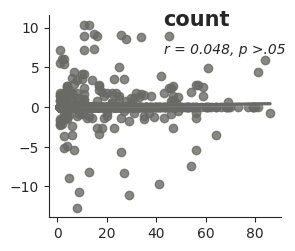

In [220]:
SAVE=True
data = pd.concat(datalist)

# Calculate the mean and standard deviation of the column
mean_value = data[statmeasure].mean()
std_value = data[statmeasure].std()

# Define the cutoff values
lower_cutoff = mean_value - 3 * std_value
upper_cutoff = mean_value + 3 * std_value

# Remove rows that are below or above 2 standard deviations from the mean
data_filtered = data[(data[statmeasure] >= lower_cutoff) & (data[statmeasure] <= upper_cutoff)]

print('removed # from SD: ', len(data)- len(data_filtered))

data= data_filtered



# Calculate the mean and standard deviation of the column
mean_value = data[metric].mean()
std_value = data[metric].std()

# Define the cutoff values
lower_cutoff = mean_value - 3 * std_value
upper_cutoff = mean_value + 3 * std_value

# Remove rows that are below or above 2 standard deviations from the mean
data_filtered = data[(data[metric] >= lower_cutoff) & (data[metric] <= upper_cutoff)]

print('removed # from SD: ', len(data)- len(data_filtered))

data= data_filtered



#########
# draw plot
###########
task='overall'
# category = 'overall'

slope, intercept, corr, pvalue, std_err = stats.linregress(data[statmeasure], data[metric])

# corr = round(pearsonr(data['backN'], data['IOR'])[0],3)
# pvalue =pearsonr(data['backN'], data['IOR'])[1]
print(f'{statmeasure} x TFP-AUC % ; r = {round(corr,3)}, {round(pvalue,3)}')

if pvalue<0.001:
    pvalue='p <.001'
elif pvalue <0.01:
    pvalue='p <.01'
elif pvalue <0.05:
    pvalue='p <.05'
else:
    pvalue='p >.05'

#     sns.set(style='white', font_scale=1.2)
sns.set_style('white', rc={
    'xtick.bottom': True,
    'ytick.left': True,
})
# sns.set(rc={"xtick.bottom" : True})

g = sns.JointGrid(data=data, x=statmeasure, y=metric) #height=5 #xlim=(0, 1), ylim=(0, 0.5)
g = g.plot_joint(sns.regplot, color="#696966", x_ci=68, ci=68) # if 68-> SE #x_estimator=np.mean, 
#     g = g.plot_marginals(sns.distplot, kde=False, bins=15, color="xkcd:bluey grey")
#     g.ax_marg_x.set_axis_off()
#     g.ax_marg_y.set_axis_off()
mean = g.ax_joint.collections[0].get_offsets()[:, 1].mean()
print('average mean estimate: ' , mean)
g.ax_marg_x.remove()
g.ax_marg_y.remove()

g.ax_joint.text(max(data[statmeasure])- 0.5*max(data[statmeasure]), max(data[metric])-2.5*data[metric].std(), f'r = {round(corr,3)}, {pvalue}', fontstyle='italic')
g.ax_joint.text(max(data[statmeasure])- 0.5*max(data[statmeasure]), max(data[metric])-0.1*data[metric].std(), statmeasure, fontweight="bold", fontsize=15)

g.fig.set_size_inches((3.5, 3))


# Axis labels and titles
#     g.set_axis_labels(xlabel='Fixation Index', ylabel='Percent of Reward Depleted (%)', fontsize=18)
g.set_axis_labels(xlabel='', ylabel='', fontsize=18)
#     g.fig.subplots_adjust(top=0.5) # adjust the Figure in rp
#     g.fig.suptitle(category)

# # Set x-axis ticks and tick labels
# #     minorLocator = MultipleLocator(1)
# majorLocator = MultipleLocator(1)
# #     g.ax_joint.xaxis.set_minor_locator(minorLocator)
# g.ax_joint.xaxis.set_major_locator(majorLocator)
# # g.ax_joint.set_xlim(range(0, 15))
# g.ax_joint.set_xticks(range(1,6))
# #     g.ax_joint.set_xticklabels(['t-1', 't-2', 't-3', 't-4', 't-5'], fontsize=15)
# g.ax_joint.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=13)
# g.ax_joint.set_yticks([0, 0.25, 0.5])
# g.ax_joint.set_yticklabels(['0%', '25%', '50%'], fontsize=13)

plt.tight_layout()
if SAVE:
    plt.savefig(f'results/tfpauc/tfpauc_{statmeasure}_{task}.pdf', dpi=300,  bbox_inches='tight')
plt.show()

# categories TFPAUC x context effects correlations

In [31]:
# TFP-AUCs by categories # use average
sdf = pd.read_csv(f'./results/context_effect_v4/support_distract_average.csv')

res = []
for task in categories:
    df = pd.read_csv(f'./results/DCBablation_v4/metric_{task}.csv')
    res.append(df[df['Ablated_Channel'].isna()]['TFP-AUCs'].item())
    
newdf = pd.DataFrame()
newdf['Target Categories'] = categories
newdf['Search Efficiency'] = res
newdf = newdf.sort_values(by='Search Efficiency')

result = pd.merge(newdf, sdf, how='inner', left_on='Target Categories', right_on='task')

result = result.round(2)
# result['average support'] = -1*result['average support']
# result['average distract'] = -1*result['average distract']
result.to_csv(f'./results/context_effect_v4/support_distract_average_modelTFPAUC.csv', index=False)

In [35]:
pearsonr(result['Search Efficiency'], result['average support'])

PearsonRResult(statistic=0.2524013392490694, pvalue=0.31227810242435394)

In [33]:
res = pearsonr(result['Search Efficiency'], result['average distract'])
res[0], round(res[1],3)

(-0.8238166384557615, 0.0)

In [34]:
result

,Target Categories,Search Efficiency,task,average support,average distract
0,knife,0.96,knife,-5.19,13.33
1,mouse,2.62,mouse,-2.18,3.64
2,car,2.80,car,-8.21,5.36
3,chair,2.82,chair,-3.69,3.97
4,bowl,2.93,bowl,-4.63,0.73
5,potted plant,2.97,potted plant,-1.57,1.57
6,fork,3.09,fork,-1.13,0.28
7,sink,3.11,sink,-7.95,1.64
8,keyboard,3.14,keyboard,-2.48,3.72
9,laptop,3.21,laptop,-2.34,3.12


In [23]:
# TFP-AUCs by categories # use sum
sdf = pd.read_csv(f'./results/context_effect_v4/support_distract_sum.csv')

res = []
for task in categories:
    df = pd.read_csv(f'./results/DCBablation_v4/metric_{task}.csv')
    res.append(df[df['Ablated_Channel'].isna()]['TFP-AUCs'].item())
    
newdf = pd.DataFrame()
newdf['Target Categories'] = categories
newdf['Search Efficiency'] = res
newdf = newdf.sort_values(by='Search Efficiency')

result = pd.merge(newdf, sdf, how='inner', left_on='Target Categories', right_on='task')

result = result.round(2)
result.to_csv(f'./results/context_effect_v4/support_distract_sum_modelTFPAUC.csv', index=False)

In [24]:
pearsonr(result['Search Efficiency'], result['average support'])

PearsonRResult(statistic=0.25217517307193255, pvalue=0.312726554276145)

In [25]:
res = pearsonr(result['Search Efficiency'], result['average distract'])
res[0], round(res[1],3)

(-0.8240252547074227, 0.0)

In [26]:
result

,Target Categories,Search Efficiency,task,average support,average distract
0,knife,0.96,knife,-25.93,66.67
1,mouse,2.62,mouse,-10.91,18.18
2,car,2.80,car,-41.07,26.79
3,chair,2.82,chair,-18.44,19.86
4,bowl,2.93,bowl,-23.17,3.66
5,potted plant,2.97,potted plant,-7.87,7.87
6,fork,3.09,fork,-5.63,1.41
7,sink,3.11,sink,-39.77,8.19
8,keyboard,3.14,keyboard,-12.39,18.58
9,laptop,3.21,laptop,-11.69,15.58


# plot using metric files

figures saved for TFP-AUCs


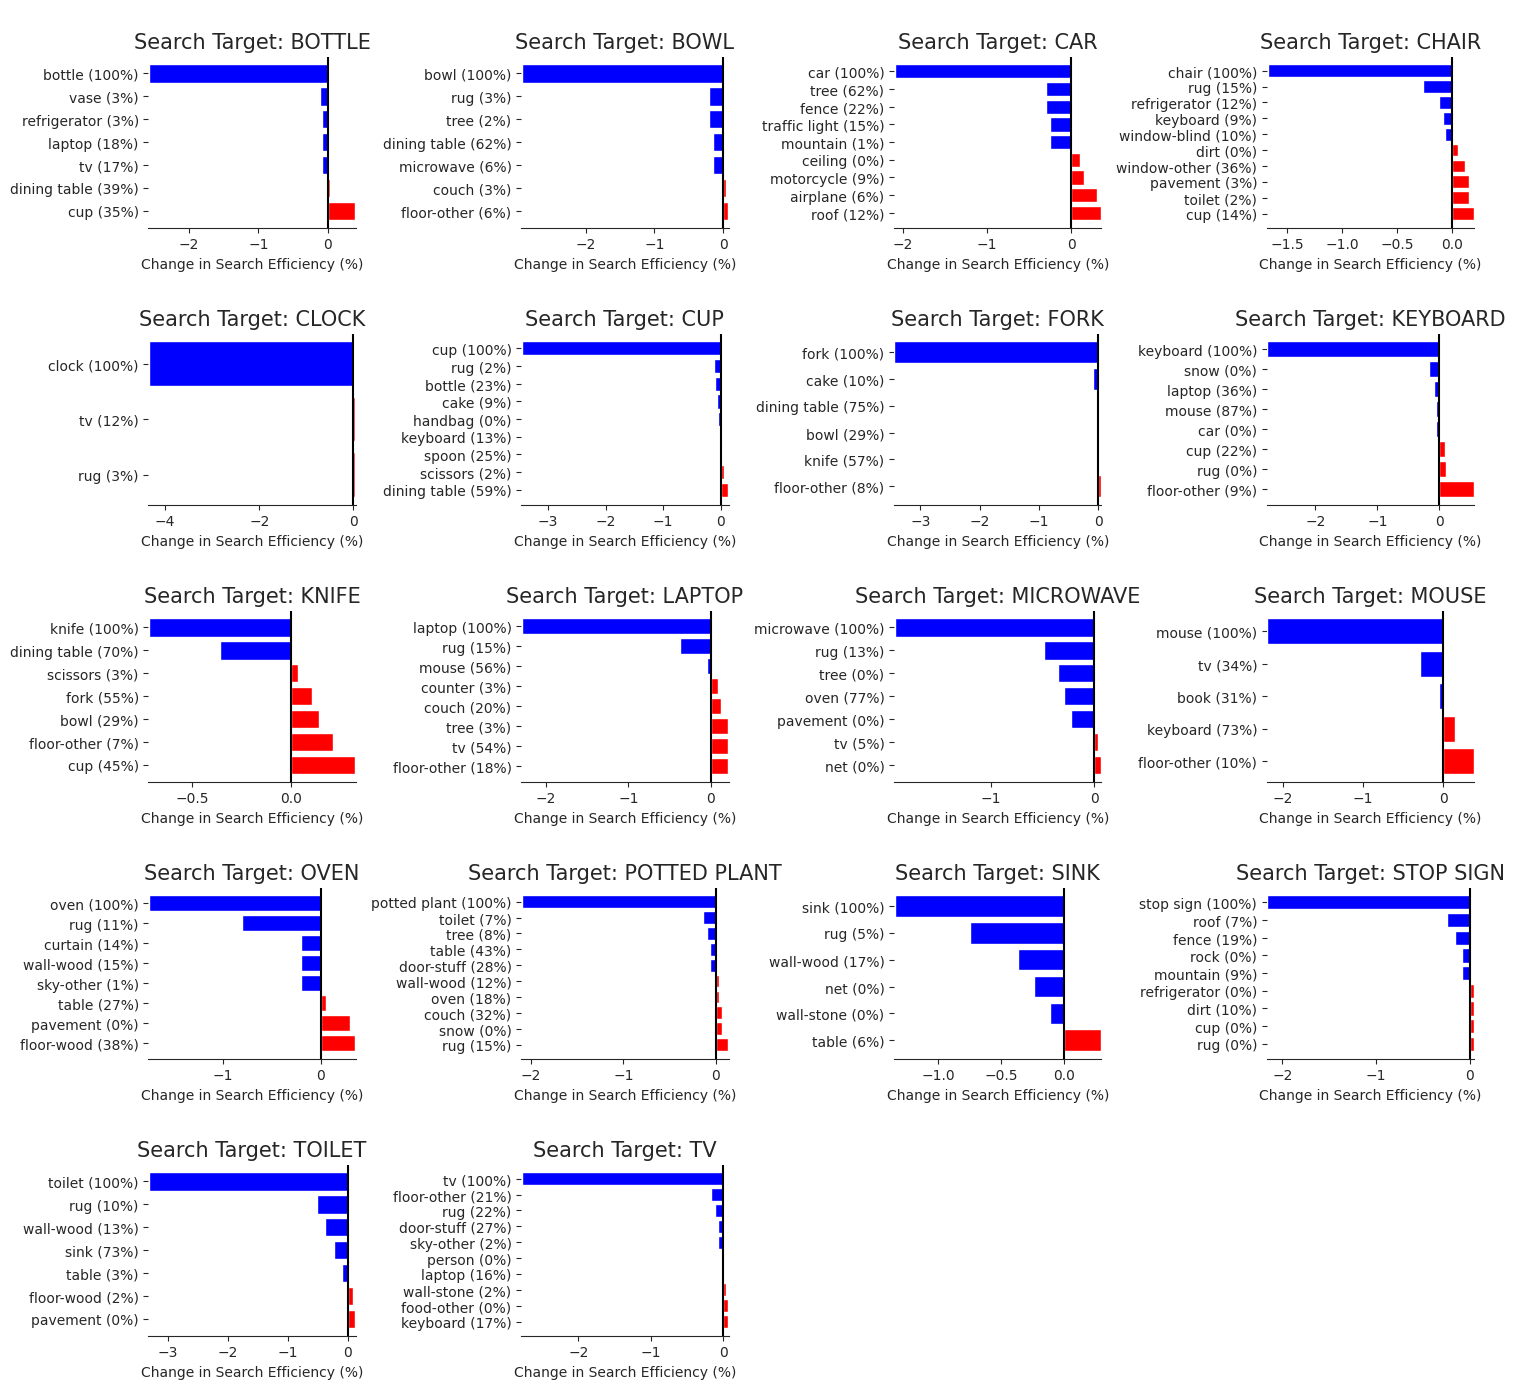

In [176]:
N_THINGS = 133 # 80 things + rest 53 are stuff categories + void cateogory
USE_TARGET = True
# metric_columns = ['TFP', 'TFP-AUCs', 'SS', 'SemSS', 'cIG', 'cNSS', 'cAUC', 'SPR']
metric_columns = ['TFP-AUCs']
metric_names = ['Search Efficiency']

for mi, metric in enumerate(metric_columns):
    metric_name = metric_names[mi]
    fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(15,14 ))
    
    for i, cat in enumerate(categories):
        df = pd.read_csv(f'results/DCBablation_v2/{cat}.csv')
        diff = (df[metric_columns] - df[metric_columns].iloc[0]).iloc[1:]
        diff['label'] = coco134labels_forlabels

        if USE_TARGET:
            usetarget='yestarget'
        else:
            usetarget='notarget'
            diff = diff[~(diff['label']==cat)].copy()
            
        k=5
        sort= diff.loc[:N_THINGS, [metric, 'label']].sort_values(by=metric, ascending=True)
        topk = sort[:k].copy()
        topk['color'] = ['blue']*len(topk)
        # topk= topk.sort_values(by='label')
        
        bottomk = sort[-k:].copy()
        bottomk['color'] = ['red']*len(topk)
        # bottomk= bottomk.sort_values(by='label')
        
        result = pd.concat([topk, bottomk])
        result = result[(result[metric]>0.0001) | (result[metric]<-0.0001)]
        
        if result[metric].nunique()==1:
            result= result.sort_values(by='label')

        ax = axes[int(i/4), i%4]
        
        if not len(result)>0:
            ax.set_xlim(0, 1)  # Set the x-axis limits
            ax.set_ylim(0, 1)  # Set the y-axis limits

            # Add "N/A" text in the center
            na_text = "N/A"
            ax.text(0.5, 0.5, na_text, fontsize=24, color='grey', ha='center', va='center')

            # Remove axis ticks and labels
            ax.axis('off')
            
        else:
            
            # fig, ax = plt.subplots(figsize=(4, 3))

            # Example data
            y_pos = np.arange(len(result))
            value = result[metric]
            
            uniquev = np.unique(value)
            
            if len(uniquev)==1:
                if uniquev[0] > 0:
                    vmax= uniquev[0]
                    vmin= 0-0.01
                else:
                    vmax= 0+0.01
                    vmin= uniquev[0]              
            else:
                vmax = max(max(value),0)
                vmin = min(min(value),0)
                
            ax.barh(y_pos, value, left=0, align='center', color=result['color'])
            ylabels =[]
            for oi, objectname in enumerate(result['label'].tolist()):
                # ylabel = result['label'].tolist()[oi]
                ylabel = objectname 
                percent = int(dcount[cat][objectname])#round(dcount[cat][objectname],0)
                ylabels.append(f'{ylabel} ({percent}%)')
                
            ax.set_yticks(y_pos, labels=ylabels) #result['label']
            ax.invert_yaxis()  # labels read top-to-bottom
            ax.set_xlim([vmin-0.005, vmax+0.005])
            ax.axvline(0, color='black')

            # Move left y-axis and bottom x-axis to centre, passing through (0,0)
            # ax.spines['left'].set_position('center')
            # ax.spines['bottom'].set_position('center')

            # Eliminate upper and right axes
            ax.spines['left'].set_color('none')
            ax.spines['right'].set_color('none')
            ax.spines['top'].set_color('none')


        ax.set_title(f'\nSearch Target: {str.upper(cat)}', fontsize=15)
        ax.set_xlabel(f'Change in {metric_name} (%)')

        # import matplotlib.patches as mpatches
        # blue_patch = mpatches.Patch(color='blue', label='Support')
        # red_patch = mpatches.Patch(color='red', label='Distractor')
        # ax.legend(handles=[blue_patch,red_patch])

        # plt.savefig(f'results/context_effect/{metric}_{cat}.pdf',  bbox_inches='tight')
        # plt.close()
        # plt.show()

    print(f'figures saved for {metric}')
    axes[-1, -1].axis('off')
    axes[-1, -2].axis('off')
    plt.tight_layout()
    # plt.subplots_adjust(left=0.065, right=0.97, top=0.96, bottom=0.065, wspace=0.14)
    plt.savefig(f'results/context_effect/{N_THINGS}_{metric}_all_{usetarget}.pdf',  bbox_inches='tight')
    plt.show()
    
# remove target category
# include stuff categories


In [104]:
# individual plot with legend
fig, ax = plt.subplots(figsize=(4, 3))

# Example data
y_pos = np.arange(len(result))
value = result[metric]
vmax = max(value)
vmin = min(value)
ax.barh(y_pos, value, left=0, align='center', color=result['color'])
ax.set_yticks(y_pos, labels=result['label'])
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlim([vmin-0.05, vmax+0.05])
ax.axvline(0, color='black')

# Move left y-axis and bottom x-axis to centre, passing through (0,0)
# ax.spines['left'].set_position('center')
# ax.spines['bottom'].set_position('center')

# Eliminate upper and right axes
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')


ax.set_title(f'Search Target: {str.upper(cat)}')
ax.set_xlabel(f'Change in {metric}')

import matplotlib.patches as mpatches
blue_patch = mpatches.Patch(color='blue', label='Support')
red_patch = mpatches.Patch(color='red', label='Distractor')
ax.legend(handles=[blue_patch,red_patch])

plt.savefig(f'results/context_effect/legend.pdf',  bbox_inches='tight')
plt.close()
# plt.show()